---
numbering: false
---

# 1.3. Absolute Loss

## The Modeling Recipe

In [Chapter 1.2](02-squared-loss-constant-model.ipynb), we implicitly introduced a three-step process for building a machine learning model.

:::{attention} The Modeling Recipe

1. **Choose a model.**

    We chose the constant model, whose predictions lie on a flat line, and don't factor in any features (like commute time).

    $$h(x_i) = w$$

    Here, $w$ is the model parameter.

1. **Choose a loss function.**

    We chose squared loss:

    $$L_\text{sq}(y_i, h(x_i)) = (y_i - h(x_i))^2$$

    This is the loss for a single data point.

    For the constant model, since $h(x_i) = w$, we have:
    
    $$L_\text{sq}(y_i, w) = (y_i - w)^2$$

1. **Minimize average loss to find optimal model parameters.**

    The average loss – also known as mean squared error here – is:

    $$R_\text{sq}(w) = \frac{1}{n} \sum_{i=1}^n (y_i - w)^2$$

    Using calculus, we found that the value of $w$ that minimizes $R_\text{sq}(w)$ is the mean of $y_1, y_2, \ldots, y_n$:

    $$w^* = \bar{y} = \frac{1}{n} \sum_{i=1}^n y_i$$

    This gave us the location of the optimal "flat line" to use in making predictions for $y_i$ given $x_i$.

:::

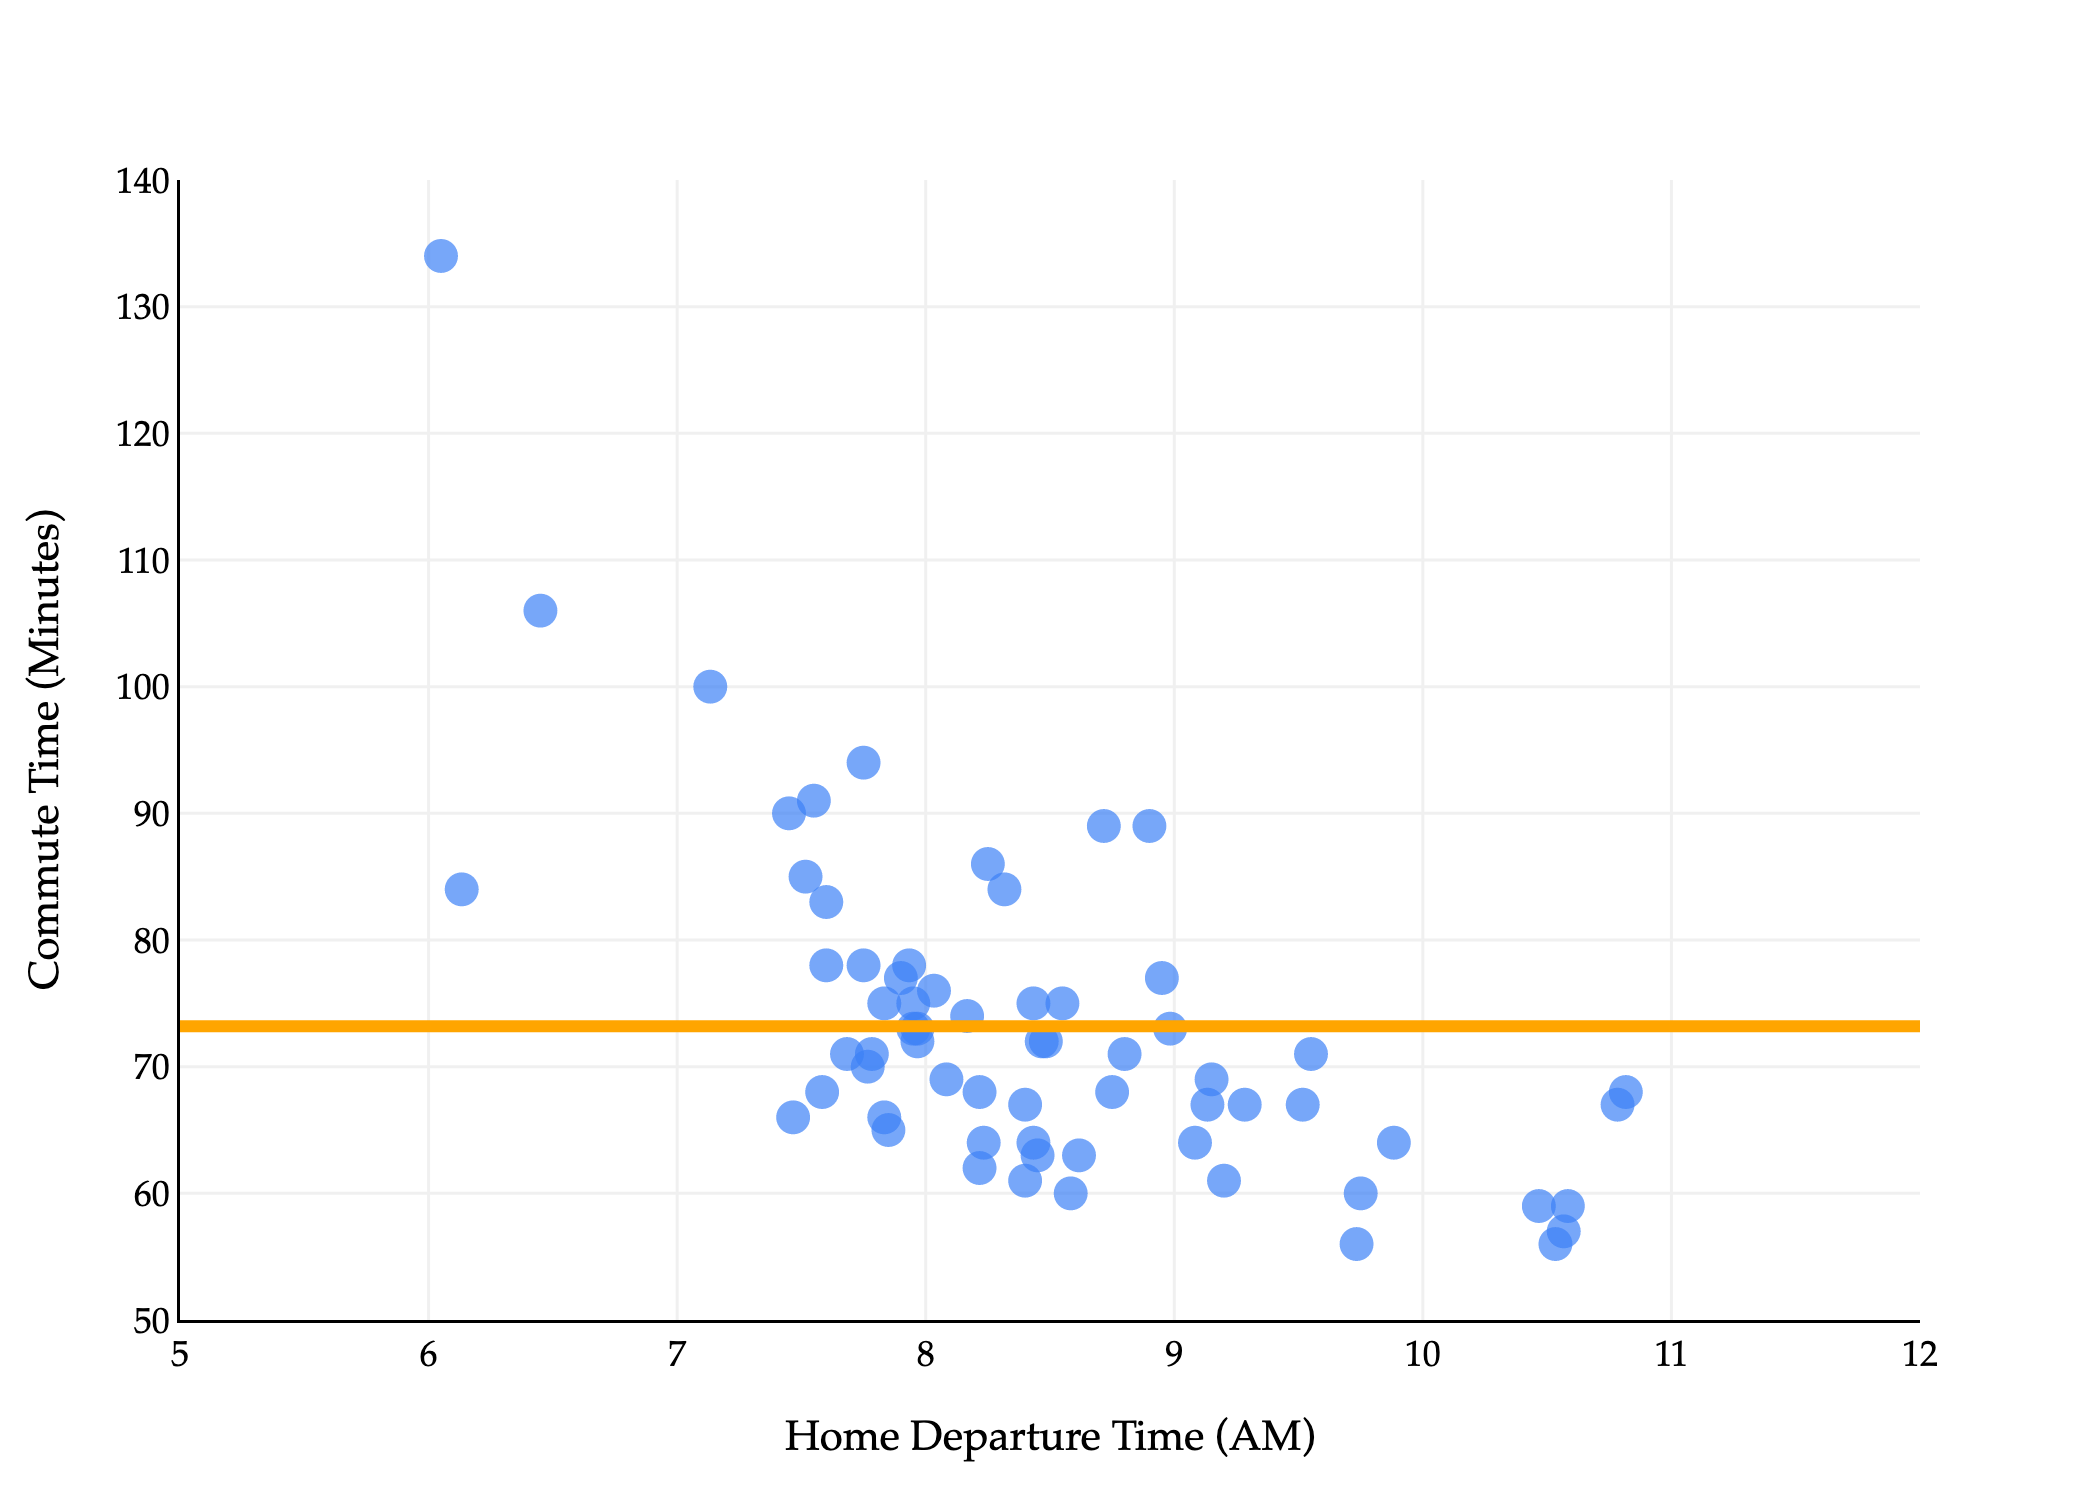

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px

df = pd.read_csv('data/commute-times.csv')
y_mean = df['minutes'].mean()

fig = px.scatter(
    df,
    x='departure_hour',
    y='minutes',
    size=np.ones(len(df)) * 50,
    size_max=8
)

fig.add_hline(
    y=y_mean,
    line_color='orange',
    line_width=4
)

fig.update_xaxes(
    title='Home Departure Time (AM)',
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
    range=[5, 12]
)
fig.update_yaxes(
    title='Commute Time (Minutes)',
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
)
fig.update_traces(marker_color="#3D81F6", marker_line_width=0)
fig.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=60, r=60, t=60, b=60),
    width=700,
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        color="black"
    ),
    showlegend=False,
)
fig.show(renderer='png', scale=3)


**Most modern supervised learning algorithms follow these same three steps**, just with different models, loss functions, and techniques for optimization. 

Another name given to this process is **empirical risk minimization**.

:::{note} Definition: Empirical Risk

**Empirical risk** is another term for "average loss across an entire dataset", and empirical risk minimization is the process of finding optimal model parameters by minimizing empirical risk.
:::

When using squared loss, all three of these mean the same thing:

- Average squared loss.
- Mean squared error.
- Empirical risk.

Risk is an idea from theoretical statistics that we'll visit in a later chapter on probability. It refers to the expected error of a model, when considering the probability distribution of the data. "Empirical" risk refers to risk calculated using an actual, concrete dataset, rather than a theoretical distribution. The reason we call the average loss $R$ is precisely because it is empirical **r**isk.

The first half of the course – and in some ways, the entire course – is focused on empirical risk minimization, and so we will make many passes through the three-step modeling recipe ourselves, with differing models and loss functions.

A common question you'll see in labs, homeworks, and exams will involve finding the optimal model parameters for a given model and loss function – in particular, for a combination of model and loss function that you've never seen before. For practice with this sort of exercise, work through the following activity. If you feel stuck, try reading through the rest of this section for context, then come back. 

:::{tip} Activity 1
:class: dropdown

Suppose we'd like to find the optimal parameter, $w^*$, for the constant model $h(x_i) = w$. To do so, we use the following loss function:

$$L(y_i, h(x_i)) = (4y_i - 3 h(x_i))^2$$

What value of $w$ minimizes average loss for this new loss function?

:::{tip} Solution
:class: dropdown

Since we're using the constant model, $h(x_i) = w$, the loss function simplifies to:

$$L(y_i, w) = (4y_i - 3 w)^2$$

Then, **average loss** is:

$$R(w) = \frac{1}{n} \sum_{i=1}^n (4y_i - 3w)^2$$

To find the $w$ that minimizes $R(w)$, we take the derivative of $R(w)$ with respect to $w$ and set it equal to 0.

\begin{align*}
\frac{\text{d}R}{\text{d}w} &= \frac{1}{n} \sum_{i=1}^n \frac{\text{d}}{\text{d}w} (4y_i - 3w)^2 \\
&= \frac{1}{n} \sum_{i=1}^n 2(4y_i - 3w)(-3) \\
&= \frac{-6}{n} \sum_{i=1}^n (4y_i - 3w)
\end{align*}

Setting the derivative equal to 0 and solving for $w$ gives

\begin{align*}
\frac{-6}{n} \sum_{i=1}^n (4y_i - 3w) &= 0 \\
\sum_{i=1}^n (4y_i - 3w) &= 0 \\
4\sum_{i=1}^n y_i - 3\sum_{i=1}^n w &= 0 \\
4\sum_{i=1}^n y_i &= 3n w \\
w &= \frac{4 \sum_{i=1}^n y_i}{3n} = \frac{4}{3} \bar{y}
\end{align*}

So, the optimal constant prediction is $w^* = \frac{4}{3} \bar{y}$. Notice that this is the mean multiplied by $\frac{4}{3}$. Is there an easy way we could have arrived at this answer without having to take the derivative?

Here's a "shortcut": let's do a substitution. Let $z_i = 4y_i$ and $t = 3w$. Then, average loss looks like:

$$R(t) = \frac{1}{n} \sum_{i=1}^n (z_i - t)^2$$

This just looks like mean squared error for the constant model, which means that

$$t* = \bar{z}$$

But since each $z_i = 4y_i$, we have $\bar{z} = 4\bar{y}$, and so $t^* = 4\bar{y}$. Since $t = 3w$, we have

$$3w^* = 4\bar{y} \implies w^* = \frac{4}{3} \bar{y}$$
:::

---

## Absolute Loss

When we first introduced the idea of a loss function, we first started by computing the error, $e_i$, of each prediction:

$$e_i={\color{3D81F6}y_i}-{\color{orange}h(x_i)}$$

where ${\color{3D81F6}y_i}$ is the <span style="color:#3D81F6; font-weight:bold">actual value</span> and ${\color{orange}h(x_i)}$ is the <span style="color:orange; font-weight:bold">predicted value</span>. 

The issue was that some errors were positive and some were negative, and so it was hard to compare them directly. We wanted the value of the loss function to be large for bad predictions and small for good predictions.

To get around this, we squared the errors, which gave us squared loss:

$$L_\text{sq}({\color{3D81F6}y_i}, {\color{orange}h(x_i)})=({\color{3D81F6}y_i}-{\color{orange}h(x_i)})^2$$

But, instead, we could have taken the absolute value of the errors. Doing so gives us **absolute loss**:

$$L_\text{abs}({\color{3D81F6}y_i}, {\color{orange}h(x_i)})=|{\color{3D81F6}y_i}-{\color{orange}h(x_i)}|$$

Below, I've visualized the absolute loss and squared loss for **just a single data point**.

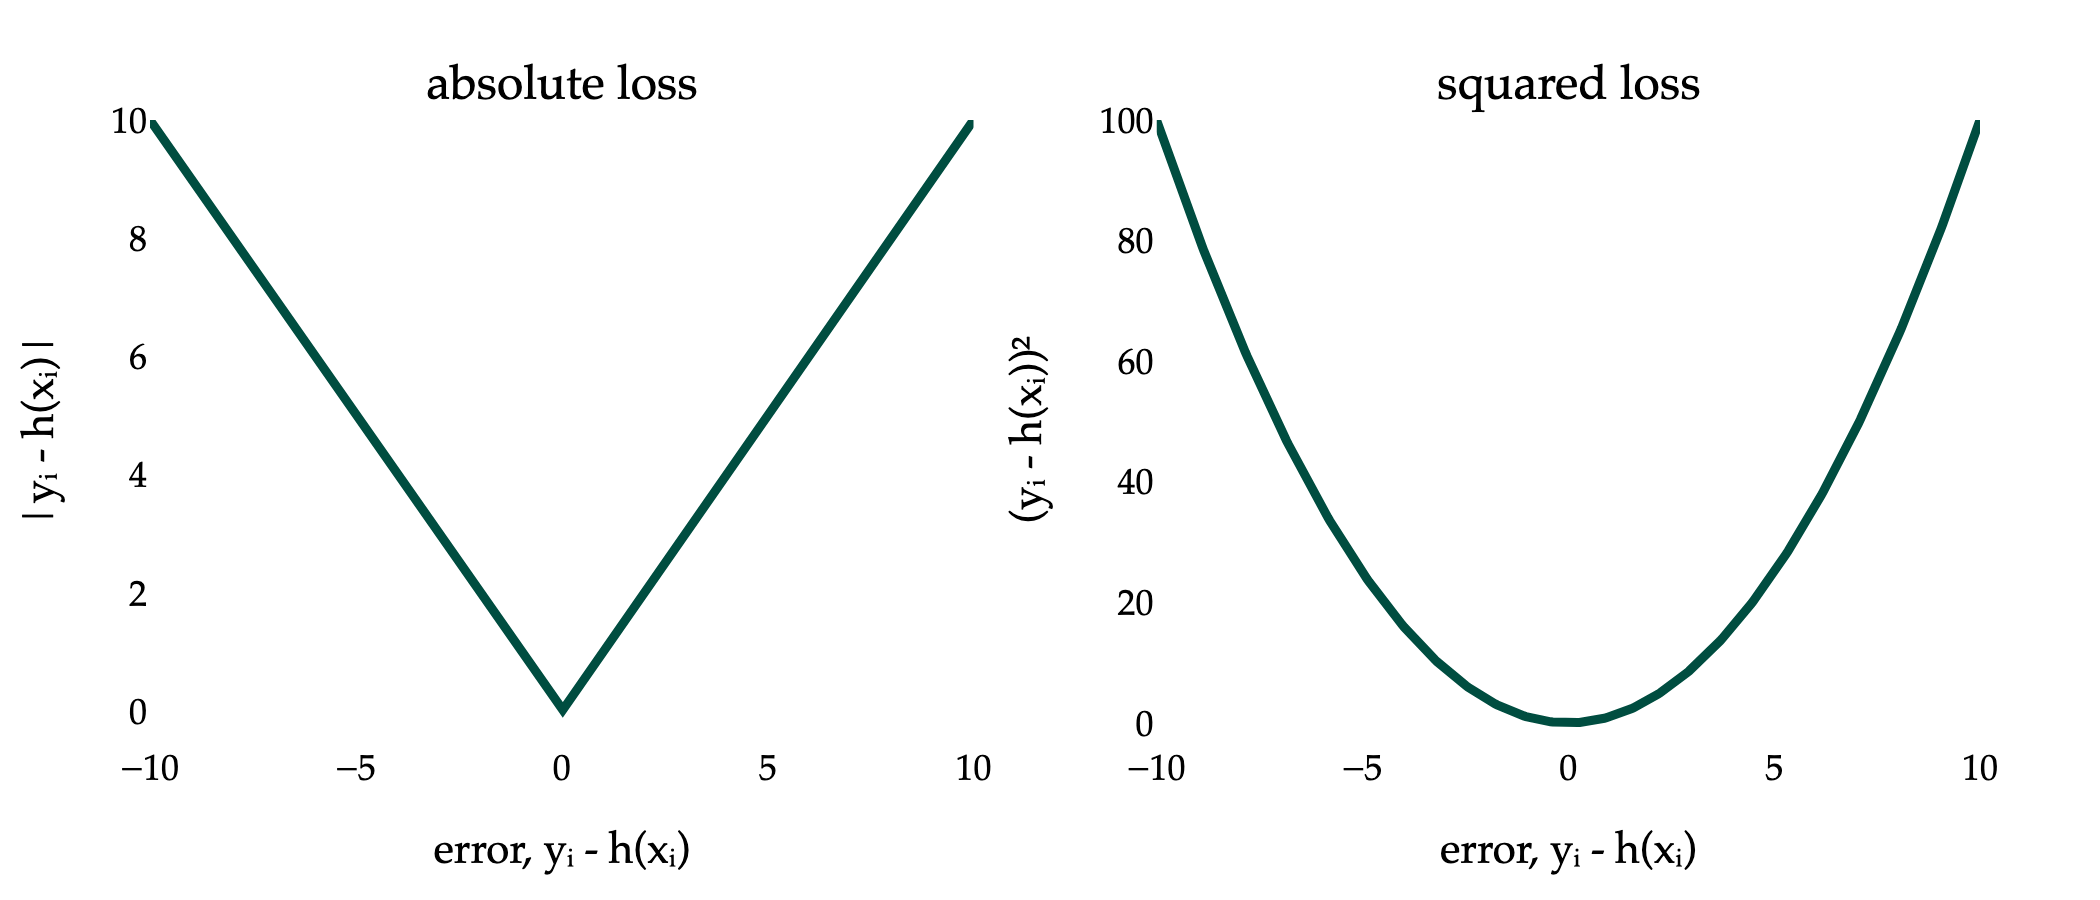

In [53]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Define range for h
h = np.linspace(-10, 10, 400)
y_i = 0

# Absolute loss: |y_i - h|
abs_loss = np.abs(y_i - h)
# Squared loss: (y_i - h)^2
sq_loss = (y_i - h) ** 2

fig = make_subplots(rows=1, cols=2, subplot_titles=("absolute loss", "squared loss"))

# Absolute loss plot
fig.add_trace(
    go.Scatter(
        x=h,
        y=abs_loss,
        mode='lines',
        line=dict(color='#004d40', width=3),
        showlegend=False
    ),
    row=1, col=1
)
fig.update_xaxes(title_text="error, yᵢ - h(xᵢ)", row=1, col=1)
fig.update_yaxes(title_text="|yᵢ - h(xᵢ)|", row=1, col=1, range=[-0.5, 10])

# Squared loss plot
fig.add_trace(
    go.Scatter(
        x=h,
        y=sq_loss,
        mode='lines',
        line=dict(color='#004d40', width=3),
        showlegend=False
    ),
    row=1, col=2
)
fig.update_xaxes(title_text="error, yᵢ - h(xᵢ)", row=1, col=2)
fig.update_yaxes(title_text="(yᵢ - h(xᵢ))²", row=1, col=2, range=[-3, 100])

fig.update_layout(
    width=700,
    height=300,
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=40, r=40, t=40, b=40),
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        color="black"
    ),
)

fig.show(renderer='png', scale=3)


You should notice two key differences between the two loss functions:

1. The absolute loss function **is not differentiable** when $y_i = h(x_i)$. The absolute value function, $f(x) = |x|$, does not have a derivative at $x=0$, because its slope to the left of $x=0$ (-1) is different from its slope to the right of $x=0$ (1). For more on this idea, see [Appendix 2](../00_math_foundations/02-derivatives.ipynb#continuity-and-differentiability).
1. The squared loss function **grows much faster** than the absolute loss function, as the prediction $h(x_i)$ gets further away from the actual value $y_i$.

We know the optimal constant prediction, $w^*$, when using squared loss, is the mean. **What is the optimal constant prediction when using absolute loss?** The answer is not still the mean; rather, the answer reflects some of these differences between squared loss and absolute loss.

Let's find that new optimal constant prediction, $w^*$, by revisiting the three-step modeling recipe.

1. **Choose a model.**

    We'll stick with the constant model, $h(x_i) = w$.

2. **Choose a loss function.**

    We'll use absolute loss:

    $$L_\text{abs}(y_i, h(x_i)) = |y_i - h(x_i)|$$

    For the constant model, since $h(x_i) = w$, we have:
    
    $$L_\text{abs}(y_i, w) = |y_i - w|$$

3. **Minimize average loss to find optimal model parameters.**

    The average loss – also known as **mean absolute error** here – is:

    $$R_\text{abs}(w) = \frac{1}{n} \sum_{i=1}^n |y_i - w|$$

In [Chapter 1.2](02-squared-loss-constant-model.ipynb), we minimized $\displaystyle R_\text{sq}(w) = \frac{1}{n} \sum_{i=1}^n (y_i - w)^2$ by taking the derivative of $R_\text{sq}(w)$ with respect to $w$ and setting it equal to 0. That will be more challenging in the case of $R_\text{abs}(w)$, because the absolute value function is not differentiable when its input is 0, as we just discussed.

---

## Mean Absolute Error for the Constant Model

We need to minimize the mean absolute error, $R_\text{abs}(w)$, for the constant model, $h(x_i) = w$, but we have to address the fact that $R_\text{abs}(w)$ is not differentiable across its entire domain.

$$R_\text{abs}(w) = \frac{1}{n} \sum_{i=1}^n |y_i - w|$$

### Graphing Mean Absolute Error

I think it'll help to visualize what $R_\text{abs}(w)$ looks like. To do so, let's reintroduce the small dataset of 5 values we used in [Chapter 1.2](02-squared-loss-constant-model.ipynb).

$$y_1=72, \quad y_2=90, \quad y_3=61, \quad y_4=85, \quad y_5=92$$

Then, $R_\text{abs}(w)$ is:

$$R_\text{abs}(w) = \frac{1}{5} (|72 - w| + |90 - w| + |61 - w| + |85 - w| + |92 - w|)$$

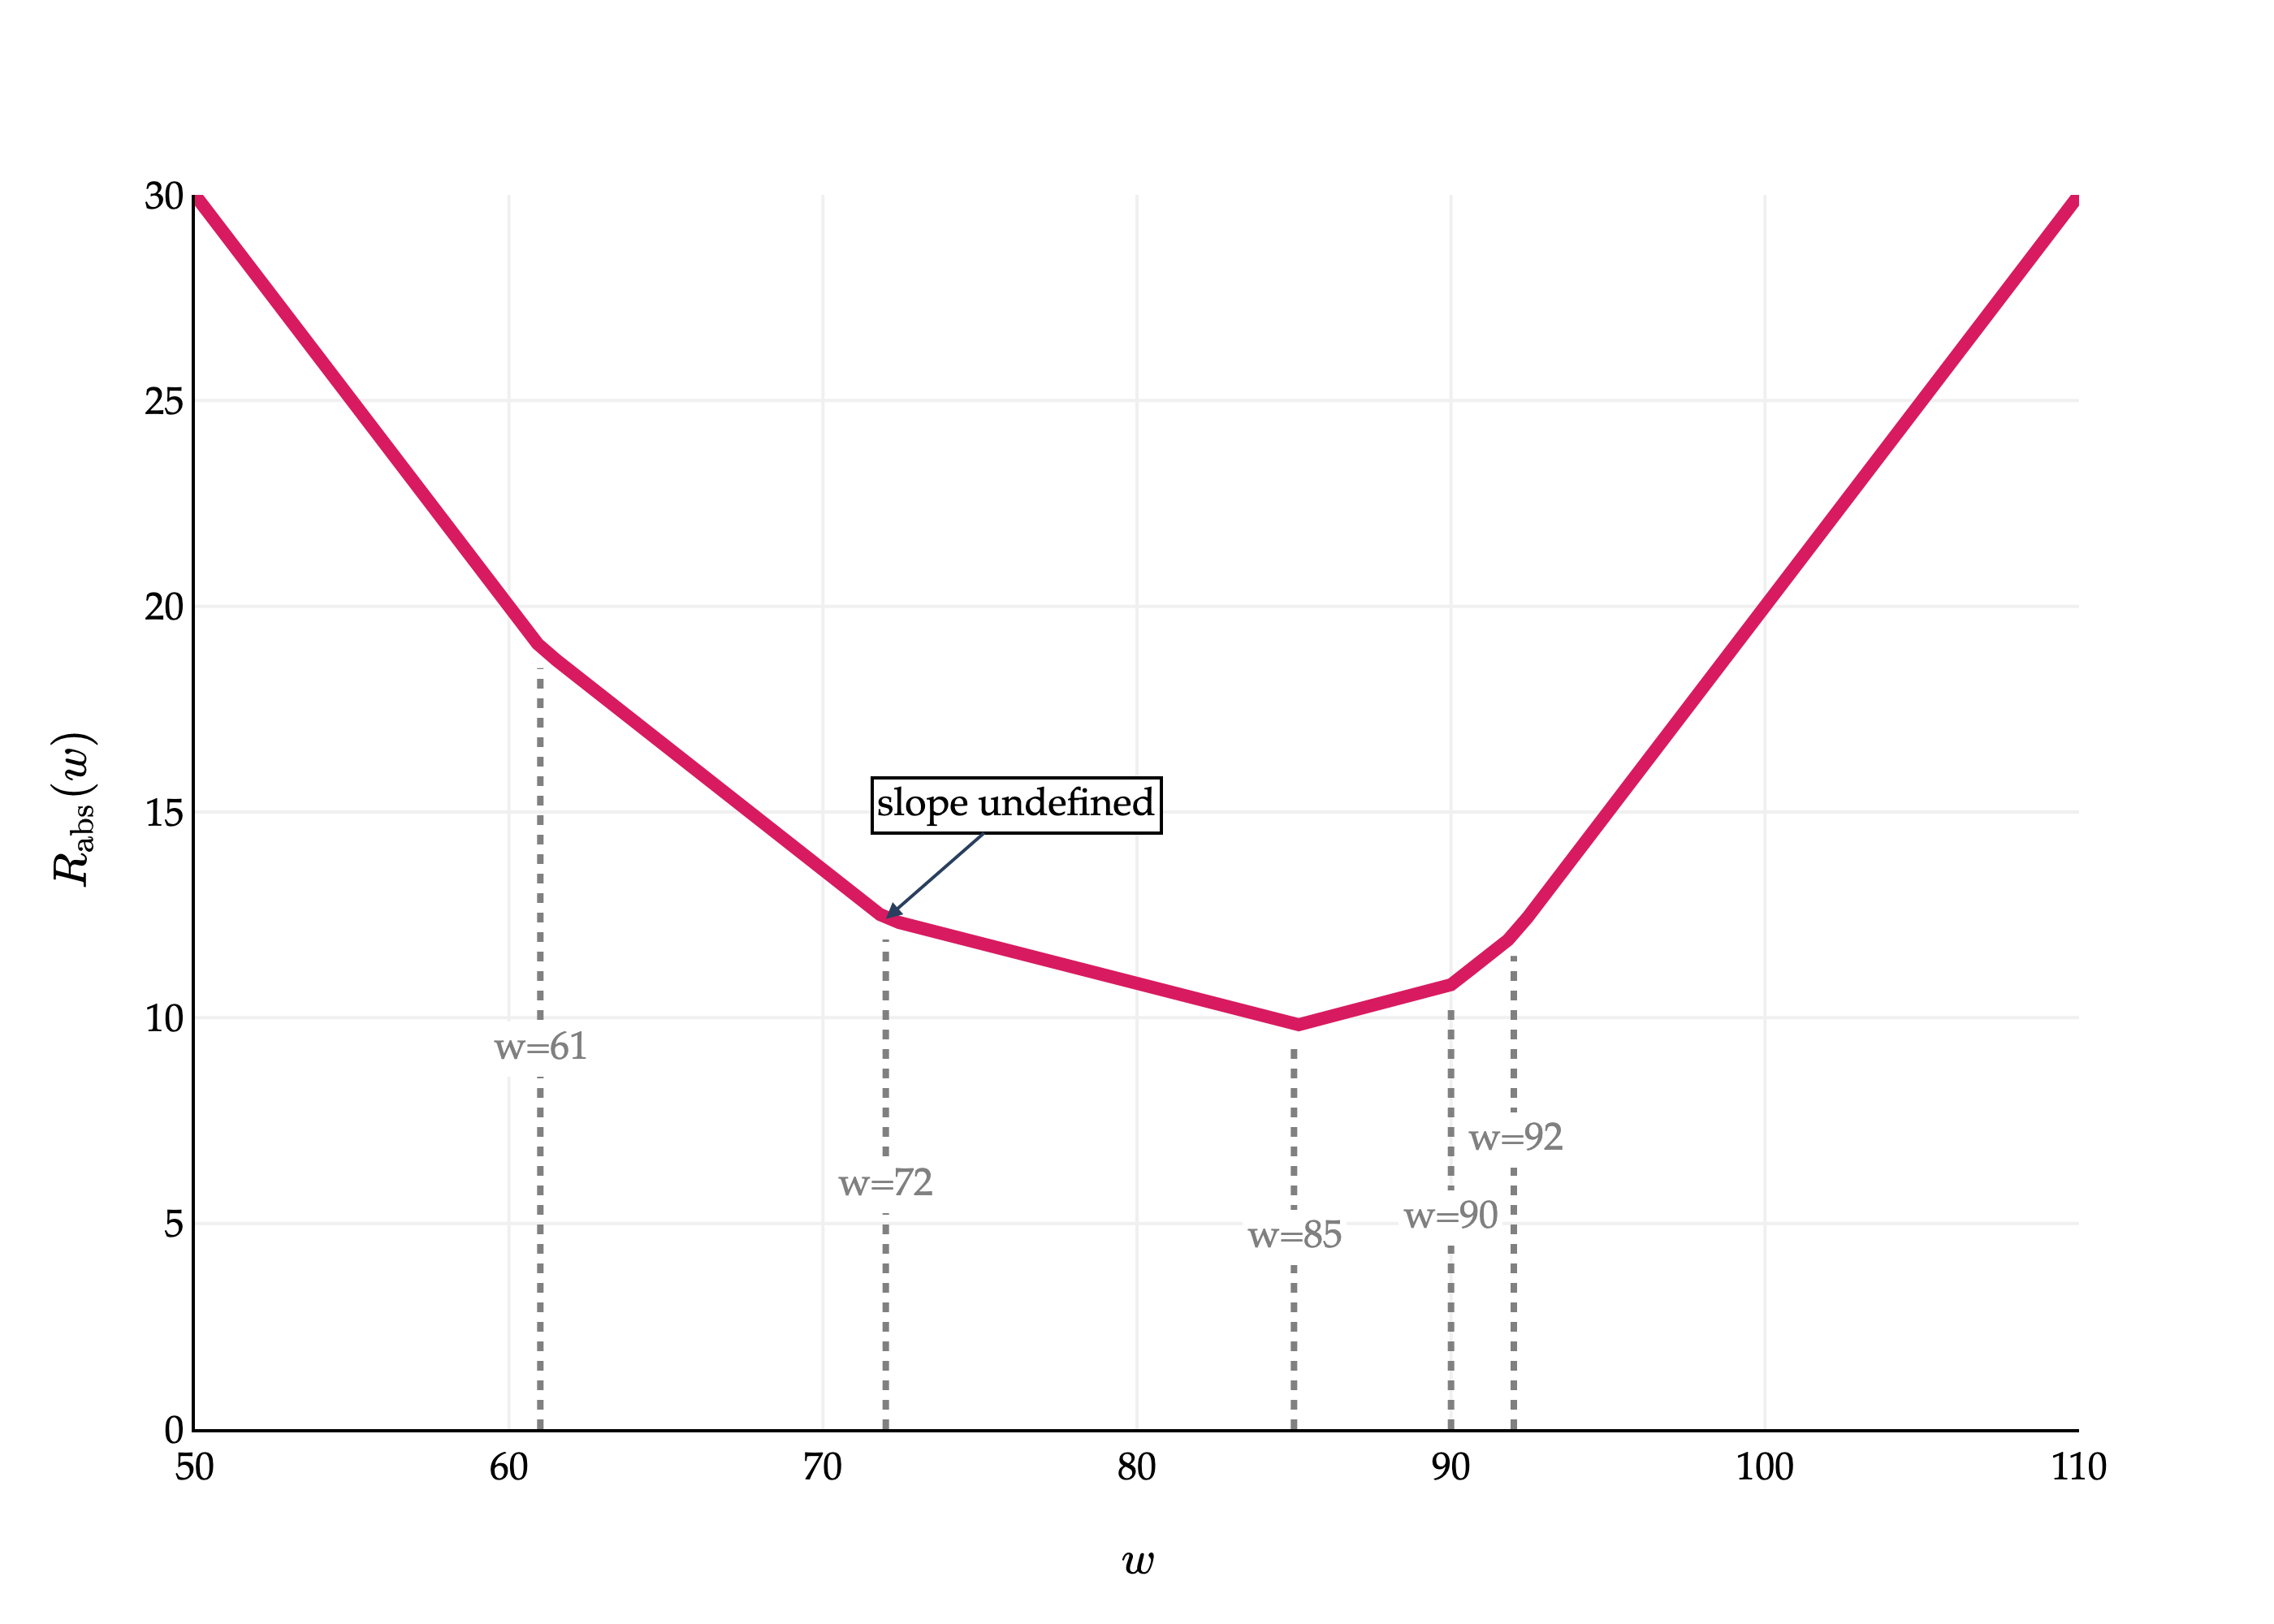

In [59]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

df = pd.read_csv('data/commute-times.csv')

f = lambda h: (abs(72-h) + abs(90-h) + abs(61-h) + abs(85-h) + abs(92-h)) / 5

x = np.linspace(50, 110, 100)
y = np.array([f(h) for h in x])

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=x, 
        y=y, 
        mode='lines', 
        name='Data', 
        line=dict(color='#D81B60', width=4)
    )
)

# Add vertical dotted lines at the 5 data points
data_points = [72, 90, 61, 85, 92]
for pt in data_points:
    y_val = f(pt)
    fig.add_trace(
        go.Scatter(
            x=[pt, pt],
            y=[0, y_val-0.5],
            mode='lines',
            line=dict(color='gray', width=2, dash='dot'),
            showlegend=False
        )
    )
    # Add annotation halfway up the dotted line
    halfway_y = (y_val-0.5) / 2 if pt != max(data_points) else y_val-5
    fig.add_annotation(
        x=pt,
        y=halfway_y,
        text=f"w={pt}",
        showarrow=False,
        font=dict(
            family="Palatino Linotype, Palatino, serif",
            color="gray",
            size=12
        ),
        bgcolor="white",
        xanchor="center",
        yanchor="middle"
    )

# Annotate (72, f(72)) with an arrow and text
fig.add_annotation(
    x=72,
    y=f(72),
    text=r"slope undefined",
    showarrow=True,
    arrowhead=2,
    ax=40,
    ay=-35,
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        color="black",
        size=12
    ),
    bgcolor="white",
    bordercolor="black"
)

fig.update_xaxes(
    showticklabels=True,
    showgrid=True,
    gridwidth=1,
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
)

fig.update_yaxes(
    showgrid=True,
    gridwidth=1,
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
    range=[0, 30]
)

fig.update_layout(
    xaxis_title=r'$w$',
    yaxis_title=r'$R_\text{abs}(w)$',
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=60, r=60, t=60, b=60),
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        color="black"
    ),
    showlegend=False
)

fig.show(renderer='png', scale=4)

This is a piecewise linear function. Where are the "bends" in the graph? Precisely where the data points, $y_1, y_2, \ldots, y_5$, are! Its at exactly these points where $R_\text{abs}(w)$ is not differentiable. At each of those points, the slope of the line segment approaching from the left is different from the slope of the line segment approaching from the right, and for a function to be differentiable at a point, the slope of the tangent line must be the same when approaching from the left and the right.

The graph of $R_\text{abs}(w)$ above, while not differentiable at any of the data points, still shows us something about the optimal constant prediction. If there is a bend at each data point, and at each bend the slope increases – that is, becomes more positive – then the optimal constant prediction seems to be in the middle, when the slope goes from negative to positive. I'll make this more precise in a moment.

For now, you might notice the value of $w$ that minimizes the graph of $R_\text{abs}(w)$ above is a familiar summary statistic, but not the mean. I won't spell it out just yet, since I'd like for you to reason about it yourself.

Let me show you one more graph of $R_\text{abs}(w)$, but this time, in a case where there are an even number of data points. Suppose we have a sixth point, $y_6=78$.

$$y_1=72, \quad y_2=90, \quad y_3=61, \quad y_4=85, \quad y_5=92, \quad y_6=78$$

Then, $R_\text{abs}(w)$ is:

$$R_\text{abs}(w) = \frac{1}{6} (|72 - w| + |90 - w| + |61 - w| + |85 - w| + |92 - w| + |78 - w|)$$

And its graph is:

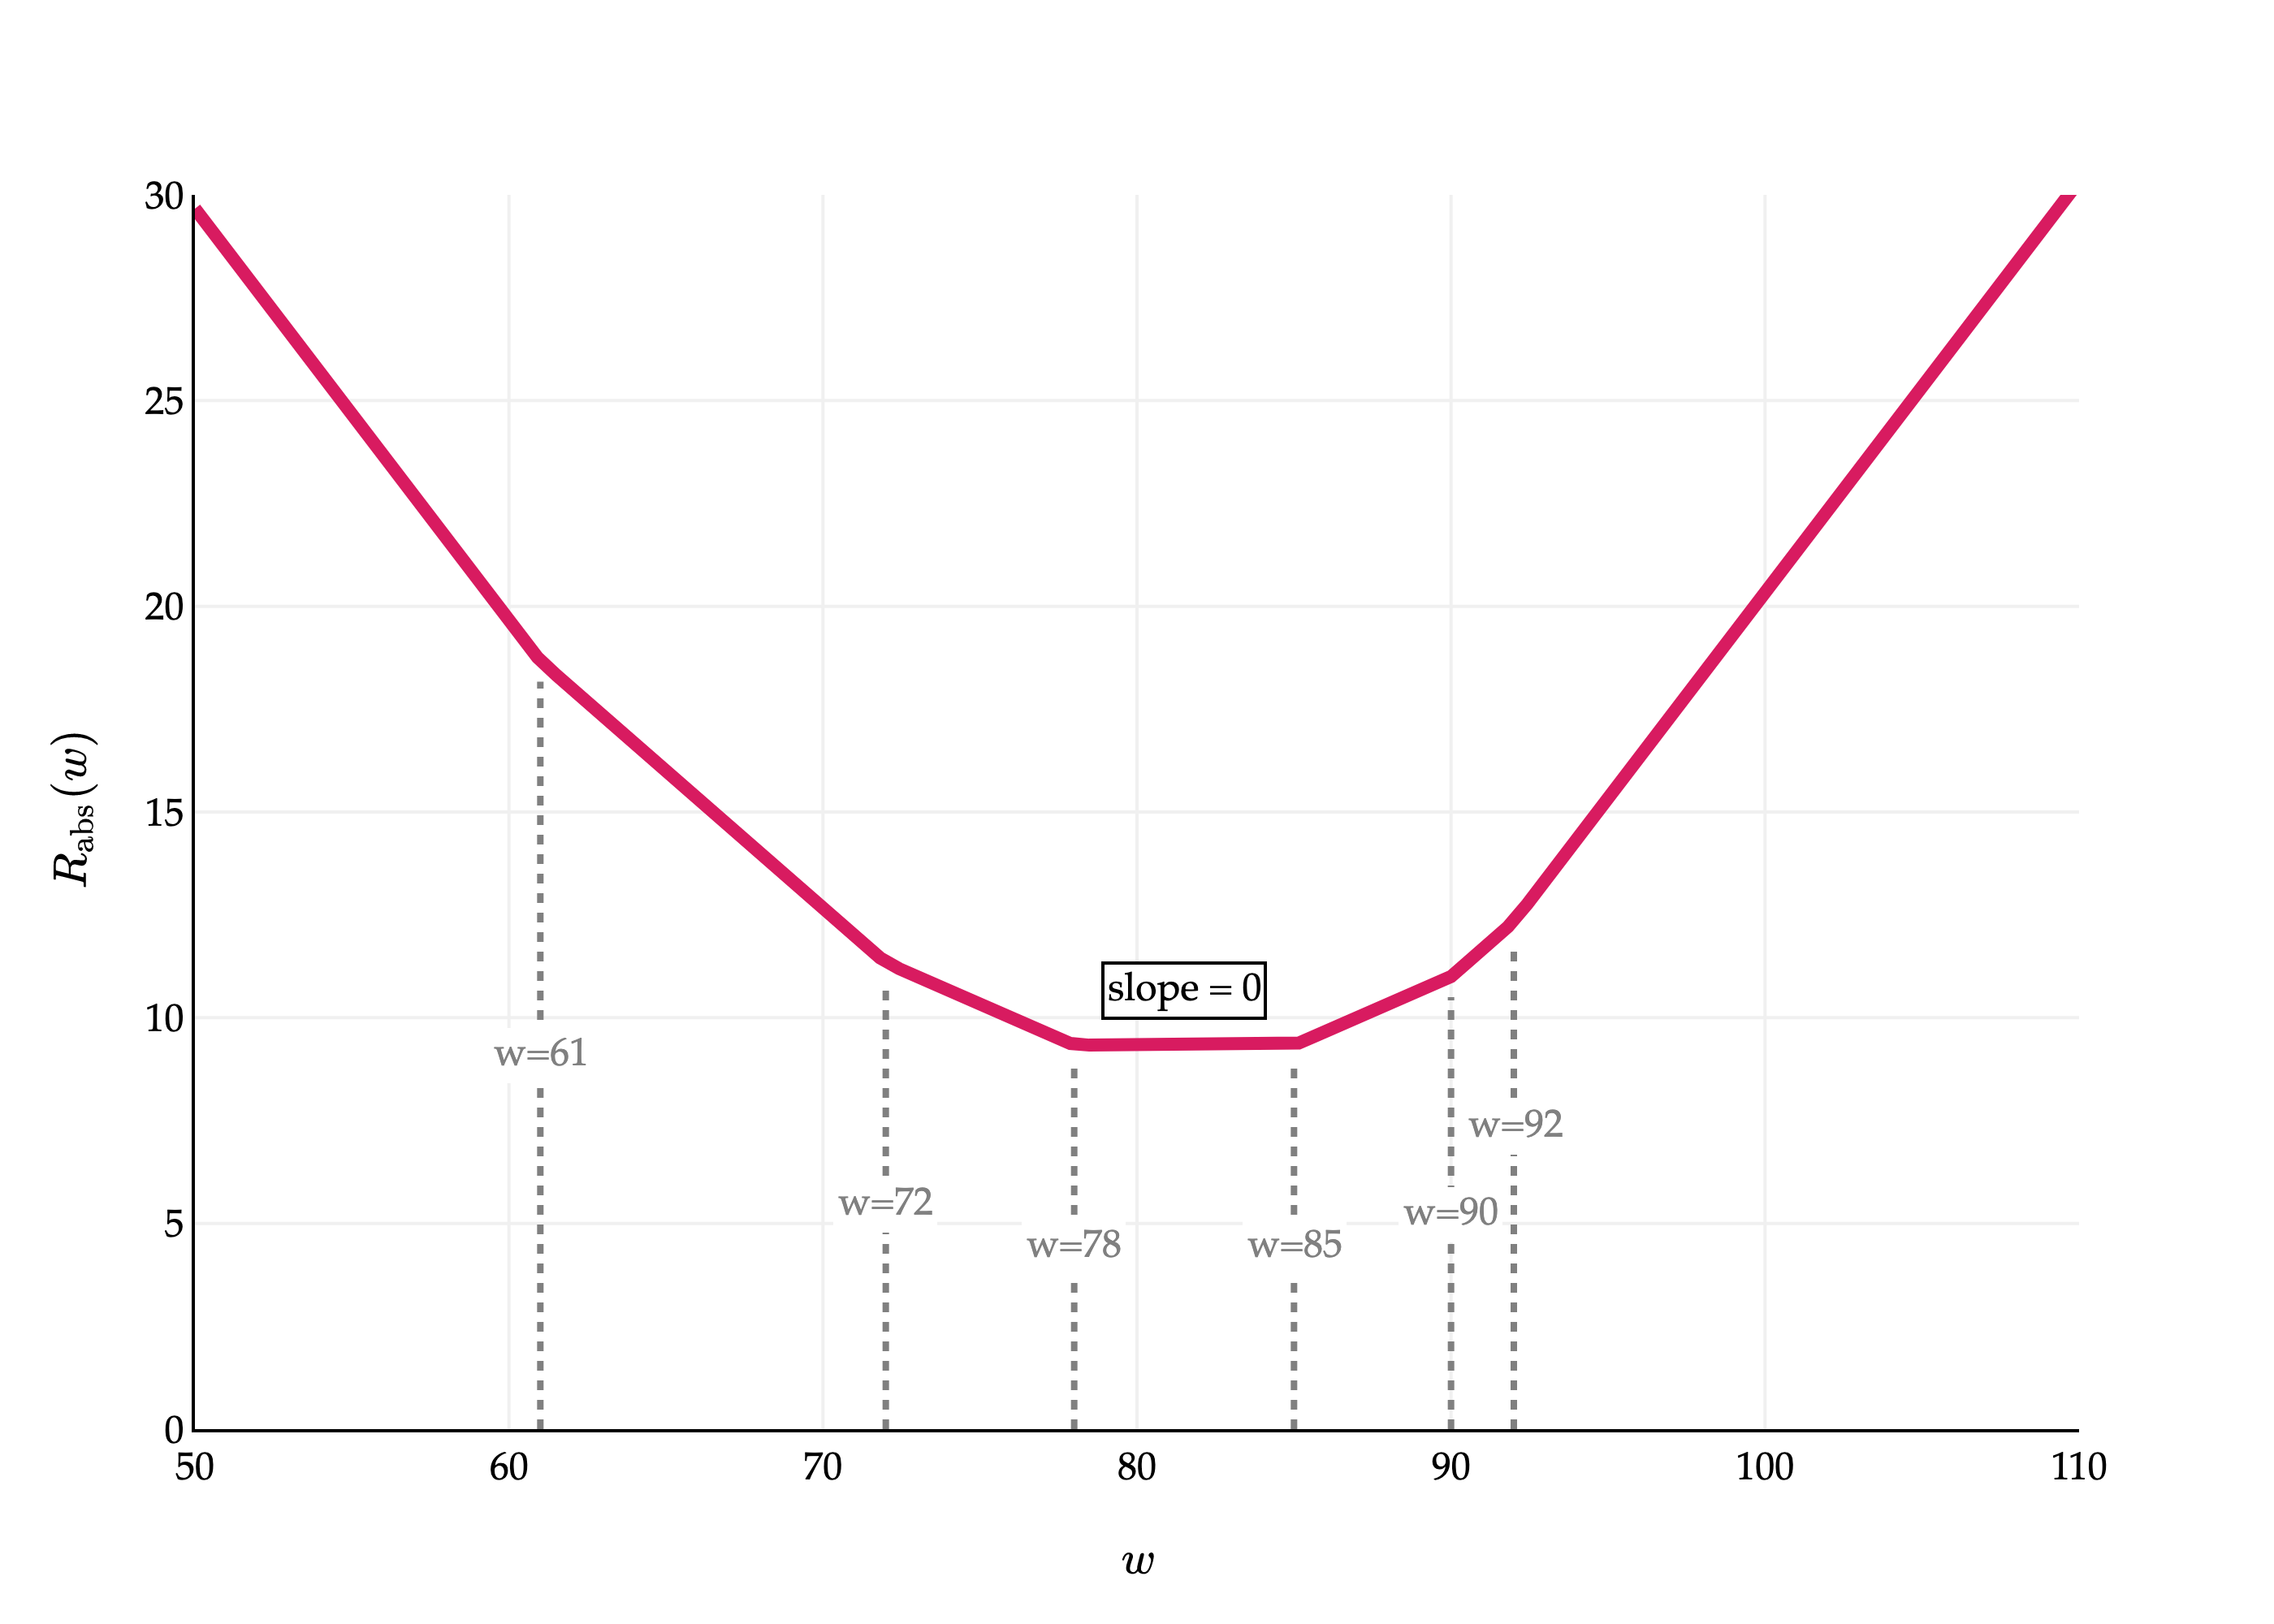

In [61]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

df = pd.read_csv('data/commute-times.csv')

f = lambda h: (abs(72-h) + abs(90-h) + abs(61-h) + abs(85-h) + abs(92-h) + abs(78 - h)) / 6

x = np.linspace(50, 110, 100)
y = np.array([f(h) for h in x])

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=x, 
        y=y, 
        mode='lines', 
        name='Data', 
        line=dict(color='#D81B60', width=4)
    )
)

data_points = [72, 90, 61, 85, 92, 78]
for pt in data_points:
    # Find the y value on the curve at this x (pt)
    y_val = f(pt)
    fig.add_trace(
        go.Scatter(
            x=[pt, pt],
            y=[0, y_val-0.5],
            mode='lines',
            line=dict(color='gray', width=2, dash='dot'),
            showlegend=False
        )
    )
    halfway_y = (y_val-0.5) / 2 if pt != max(data_points) else y_val-5
    fig.add_annotation(
        x=pt,
        y=halfway_y,
        text=f"w={pt}",
        showarrow=False,
        font=dict(
            family="Palatino Linotype, Palatino, serif",
            color="gray",
            size=12
        ),
        bgcolor="white",
        xanchor="center",
        yanchor="middle"
    )

# Annotate the flat region between the middle two points with a box that says slope = 0
sorted_points = sorted(data_points)
mid1, mid2 = sorted_points[2], sorted_points[3]
# Find the y value at the midpoint for annotation placement
mid_x = (mid1 + mid2) / 2
mid_y = f(mid_x)

# Add annotation box
fig.add_annotation(
    x=mid_x,
    y=mid_y+1.3,
    text="slope = 0",
    showarrow=False,
    font=dict(size=12, color="black"),
    bordercolor="black",
    bgcolor="white",
    borderwidth=1,
    # borderpad=4
)

fig.update_xaxes(
    showticklabels=True,
    showgrid=True,
    gridwidth=1,
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
)

fig.update_yaxes(
    showgrid=True,
    gridwidth=1,
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
    range=[0, 30]
)

fig.update_layout(
    xaxis_title=r'$w$',
    yaxis_title=r'$R_\text{abs}(w)$',
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=60, r=60, t=60, b=60),
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        color="black"
    ),
    showlegend=False
)

fig.show(renderer='png', scale=4)

This graph is broken into 7 segments, with 6 bends (one per data point). Between the 3rd and 4th bends – that is, the 3rd and 4th data points – the slope is 0, and **all values in that interval** minimize $R_\text{abs}(w)$. So, it seems that the value of $w^*$ doesn't have to be unique!

### Minimizing Mean Absolute Error

From the two graphs above, you may have a clear picture of what the optimal constant prediction, $w^*$, is. But, to avoid relying too heavily on visual intuition and just a single set of example data points, let's try and minimize $R_\text{abs}(w)$ mathematically, for an arbitrary set of data points.

To be clear, the goal is to minimize:

$$R_\text{abs}(w) = \frac{1}{n} \sum_{i=1}^n |y_i - w|$$

To do so, we'll take the derivative of $R_\text{abs}(w)$ with respect to $w$ and set it equal to 0.

$$\frac{\text{d}}{\text{d}w} R_\text{abs}(w) = \frac{\text{d}}{\text{d}w} \left( \frac{1}{n} \sum_{i=1}^n |y_i - w| \right)$$

Using the familiar facts that the derivative of a sum is the sum of the derivatives, **and** that constants can be pulled out of the derivative, we have:

$$\frac{\text{d}}{\text{d}w} R_\text{abs}(w) = \frac{1}{n} \sum_{i=1}^n \frac{\text{d}}{\text{d}w} |y_i - w|$$

Here's where the challenge comes in. What is $\frac{\text{d}}{\text{d}w} |y_i - w|$?

Let's start by remembering the derivative of the absolute value function. The absolute value function itself can be thought of as a piecewise function:

$$|x| = \begin{cases}
    x & x \geq 0 \\
    -x & x < 0
\end{cases}$$

Note that the $x=0$ case can either lumped in either the $x$ or $-x$ case, since $0$ and $-0$ are both $0$.

Using this logic, I'll write $|y_i - w|$ as a piecewise of $w$:

$$|y_i - w| = \begin{cases}
    y_i - w & w \leq y_i \\
    w - y_i & w > y_i
\end{cases}$$

I have written the two conditions with $w$ on the left, since it's easier to think in terms of $w$ in my mind, but this means that the inequalities are flipped relative to how I presented them in the definition of $|x|$. Remember, $|y_i - w|$ is a function of $w$; we're treating $y_i$ as some constant. If it helps, replace every instance of $y_i$ with a concrete number, like $5$, then reason through the resulting graph.

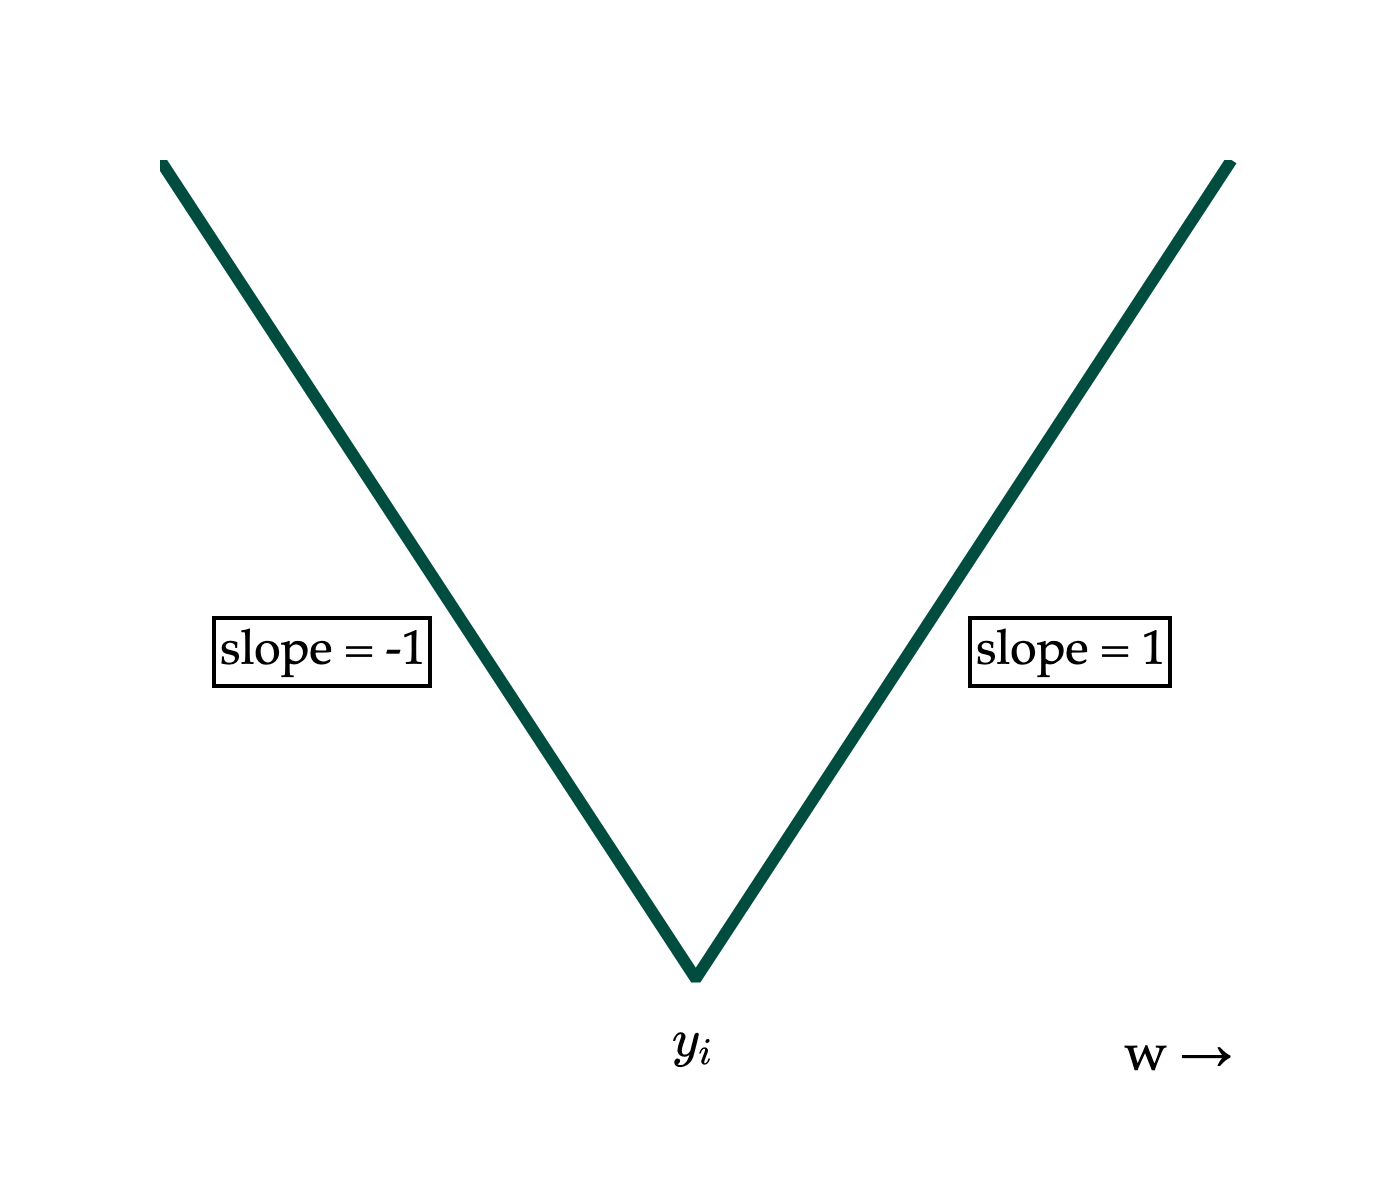

In [66]:
import numpy as np
import plotly.graph_objects as go

h = np.linspace(-10, 10, 400)
y_i = 0

abs_loss = np.abs(y_i - h)

fig = go.Figure(
    data=go.Scatter(
        x=h,
        y=abs_loss,
        mode='lines',
        line=dict(color='#004d40', width=3),
        showlegend=False
    )
)

# Annotate left side (slope = 1)
fig.add_annotation(
    x=-7,
    y=4,
    text="slope = -1",
    showarrow=False,
    font=dict(size=12, color="black"),
    align="center",
    bordercolor="black"
)

# Annotate right side (slope = -1)
fig.add_annotation(
    x=7,
    y=4,
    text="slope = 1",
    showarrow=False,
    font=dict(size=12, color="black"),
    align="center",
    bordercolor="black",
)

# Annotate y_i at x=0
fig.add_annotation(
    x=0,
    y=-0.5,
    text="$y_i$",
    showarrow=False,
    font=dict(size=13, color="black"),
    yanchor="top"
)

# Annotate "w ->" towards the right of the x-axis
fig.add_annotation(
    x=9,
    y=-0.5,
    text="w →",
    showarrow=False,
    font=dict(size=13, color="black"),
    yanchor="top"
)

fig.update_xaxes(showticklabels=False, title_text=None)
fig.update_yaxes(showticklabels=False, title_text=None, range=[-0.75, 10])

fig.update_layout(
    width=350,
    height=300,
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=40, r=40, t=40, b=40),
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        color="black"
    ),
)

fig.show(renderer='png', scale=4)


Now we can take the derivative of each piece:

$$\frac{\text{d}}{\text{d}w} |y_i - w| = \begin{cases}
    -1 & w < y_i \\
    \text{undefined} & w = y_i \\
    1 & w > y_i
\end{cases}$$

Great. Remember, this is the derivative of the absolute loss for a single data point. But our main objective is to find the derivative of the average absolute loss, $R_\text{abs}(w)$. Using this piecewise definition of $\frac{\text{d}}{\text{d}w} |y_i - w|$, we have:

$$\begin{align*}
\frac{\text{d}}{\text{d}w} R_\text{abs}(w) &= \frac{1}{n} \sum_{i=1}^n \frac{\text{d}}{\text{d}w} |y_i - w| \\
&= \frac{1}{n} \sum_{i=1}^n \begin{cases}
    -1 & w < y_i \\
    \text{undefined} & w = y_i \\
    1 & w > y_i
\end{cases}
\end{align*}$$

At any point where $w = y_i$, for any value of $i$, $\frac{\text{d}}{\text{d}w} R_\text{abs}(w)$ is undefined. (This makes any point where $w = y_i$ a critical point.) Let's exclude those values of $w$ from our consideration. In all other cases, the sum in the expression above involves only two possible values: $-1$ and $1$.

- The sum adds $-1$ for all data points greater than $w$, i.e. where $w < y_i$.
- The sum adds $1$ for all data points less than $w$, i.e. where $w > y_i$.

Using some creative notation, I'll re-write $\frac{\text{d}}{\text{d}w} R_\text{abs}(w)$ as:

$$\frac{\text{d}}{\text{d}w} R_\text{abs}(w) = \frac{1}{n} \left( \sum_{w < y_i} -1 + \sum_{w > y_i} 1 \right)$$

The sum $\displaystyle \sum_{w < y_i} -1$ is the sum of $-1$ for all data points greater than $w$, so perhaps a more intuitive way to write it is:

$$\sum_{w < y_i} -1 = \underbrace{(-1) + (-1) + \ldots + (-1)}_{\text{add once per data point \\ to the right of } w} = -(\text{\# right of } w)$$

Equivalently, $\displaystyle \sum_{w > y_i} 1 = (\text{\# left of } w)$, meaning that:

$$\begin{align*} \frac{\text{d}}{\text{d}w} R_\text{abs}(w) &= \frac{1}{n} \left( -(\text{\# right of } w) + (\text{\# left of } w) \right) \end{align*}$$

$$\boxed{\frac{\text{d}}{\text{d}w}R_{\text{abs}}(w) = \frac{\text{\# of points left of }w-\text{\# of points right of }w}{n}}, \qquad w\notin\{y_1,\ldots,y_n\}$$

By "left of $w$", I mean less than $w$.

This boxed form gives us the slope of $R_\text{abs}(w)$, for any point $w$ that is **not** an original data point. To put it in perspective, let's revisit the first graph we saw in this section, where we plotted $R_\text{abs}(w)$ for the dataset:

$$y_1=72, \quad y_2=90, \quad y_3=61, \quad y_4=85, \quad y_5=92$$

$$R_\text{abs}(w) = \frac{1}{5} (|72 - w| + |90 - w| + |61 - w| + |85 - w| + |92 - w|)$$

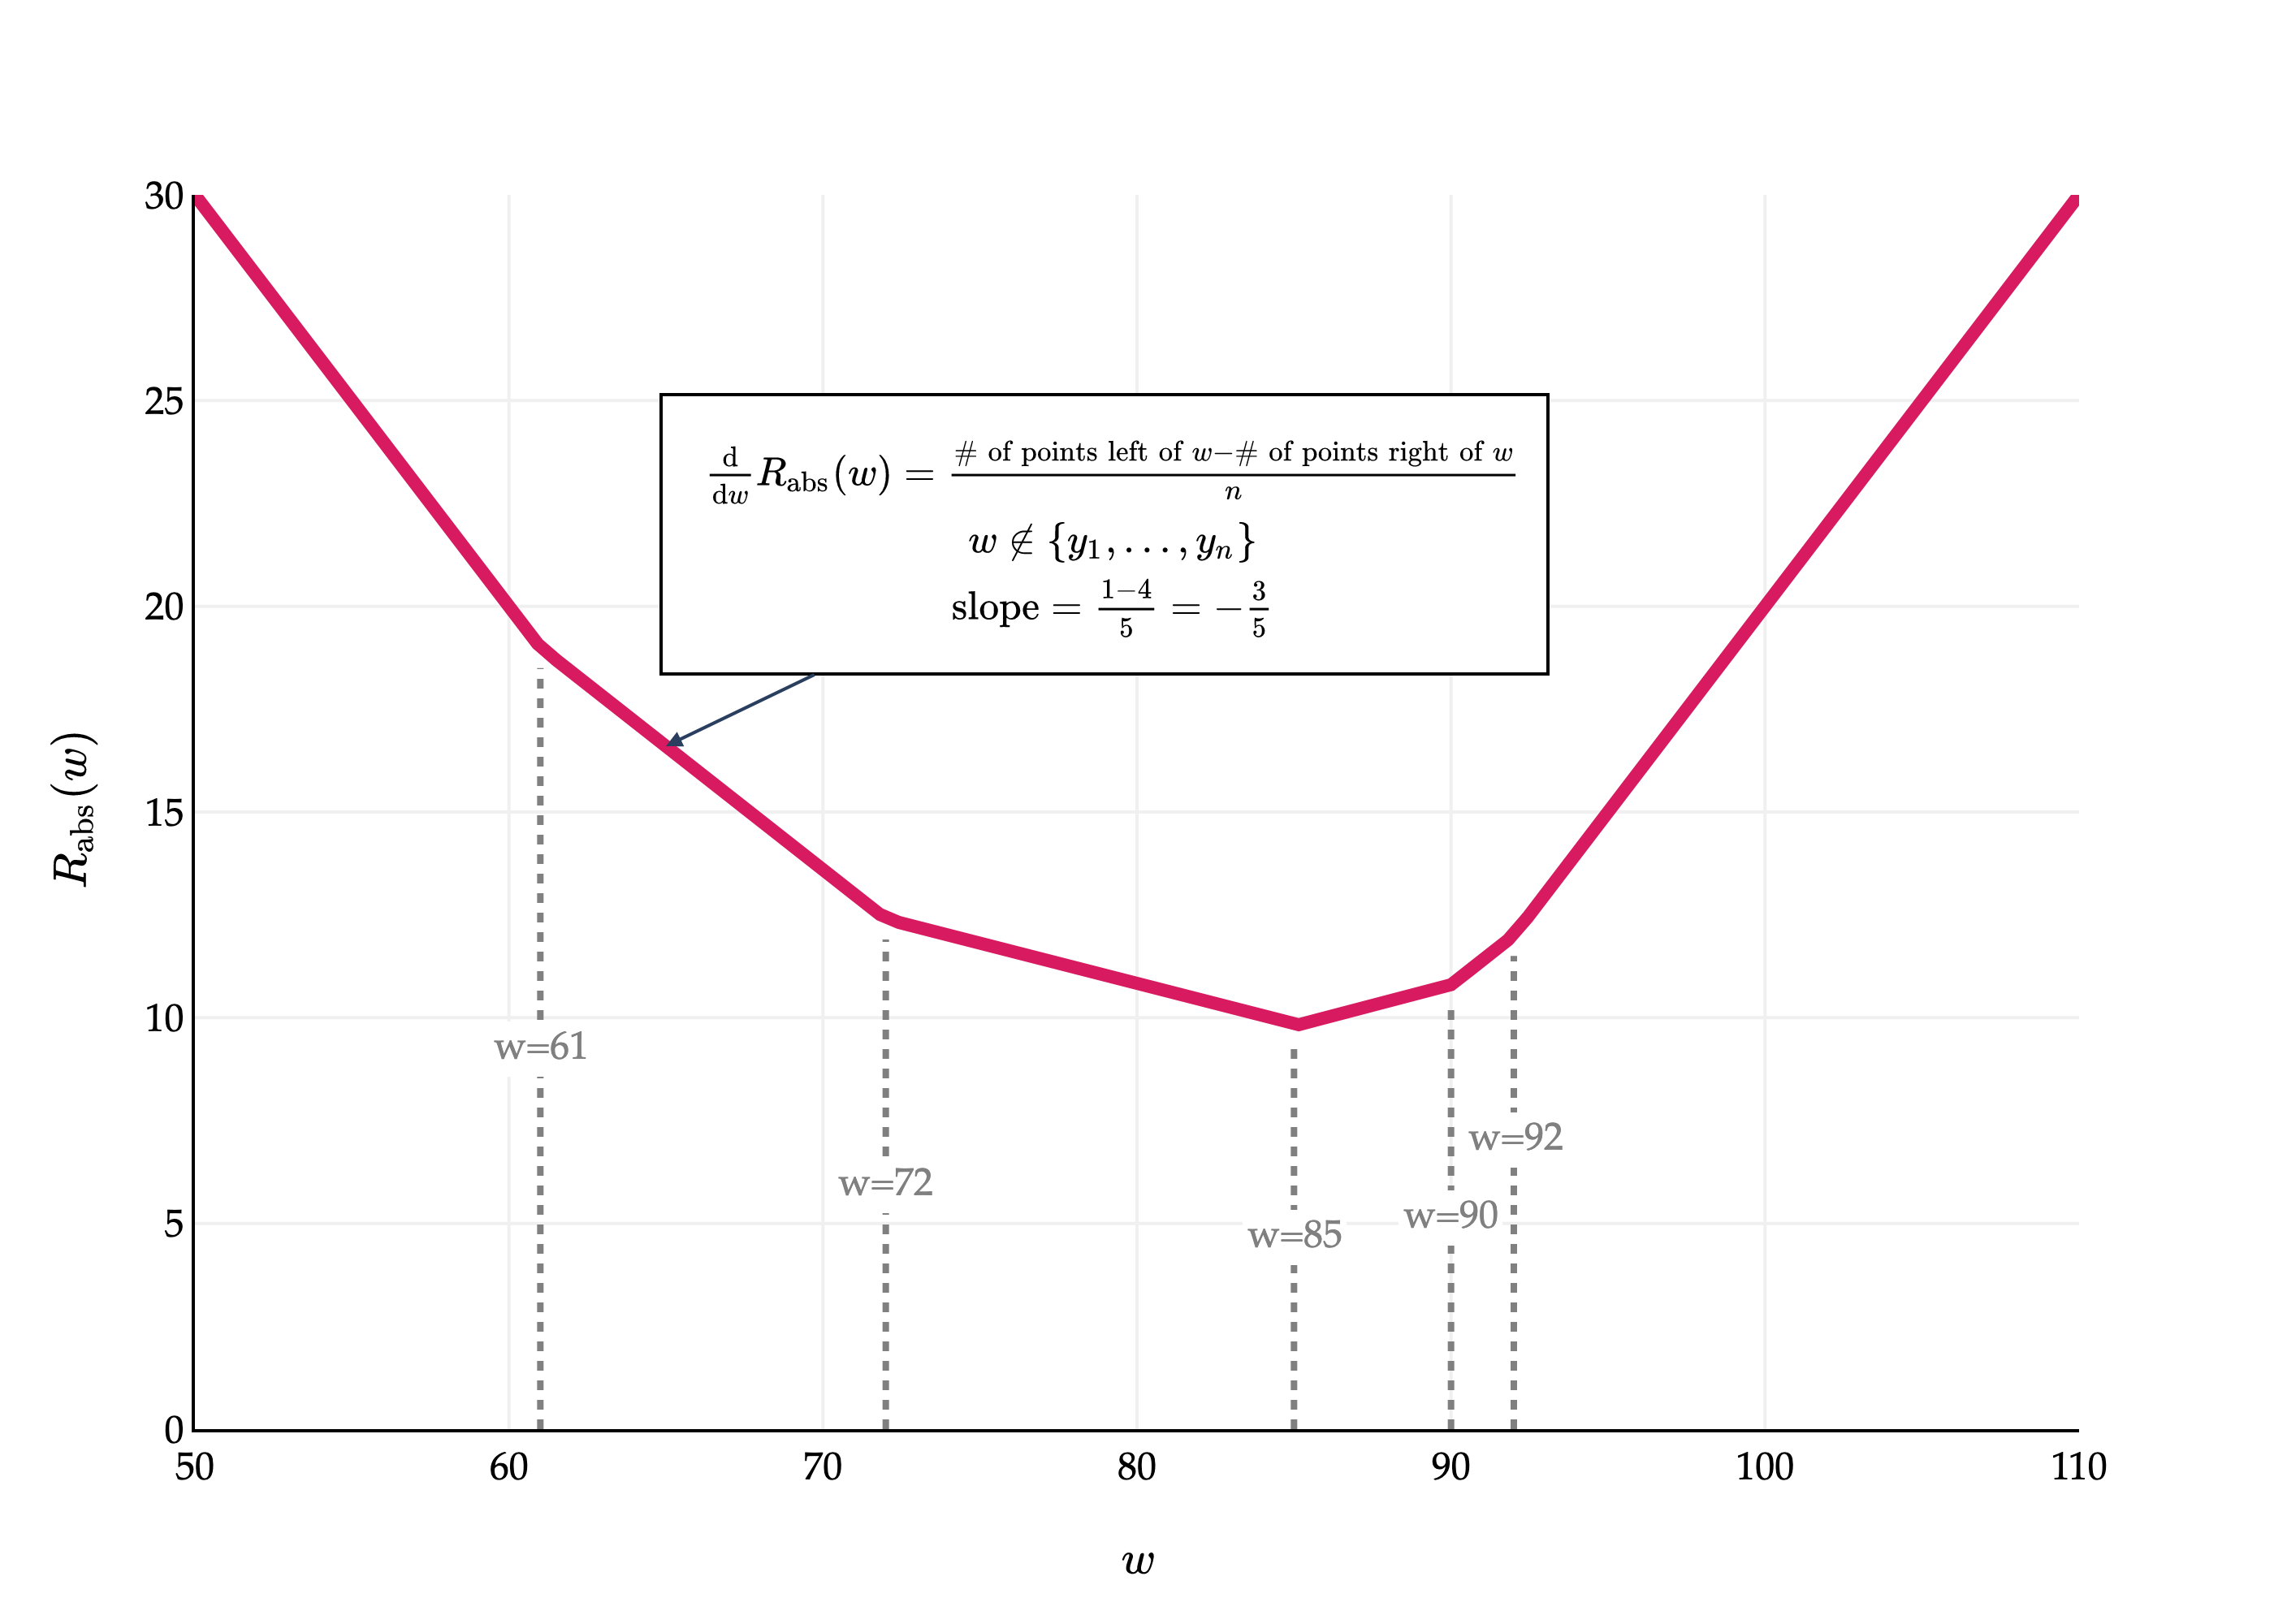

In [73]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

df = pd.read_csv('data/commute-times.csv')

f = lambda h: (abs(72-h) + abs(90-h) + abs(61-h) + abs(85-h) + abs(92-h)) / 5

x = np.linspace(50, 110, 100)
y = np.array([f(h) for h in x])

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=x, 
        y=y, 
        mode='lines', 
        name='Data', 
        line=dict(color='#D81B60', width=4)
    )
)

# Add vertical dotted lines at the 5 data points
data_points = [72, 90, 61, 85, 92]
for pt in data_points:
    y_val = f(pt)
    fig.add_trace(
        go.Scatter(
            x=[pt, pt],
            y=[0, y_val-0.5],
            mode='lines',
            line=dict(color='gray', width=2, dash='dot'),
            showlegend=False
        )
    )
    # Add annotation halfway up the dotted line
    halfway_y = (y_val-0.5) / 2 if pt != max(data_points) else y_val-5
    fig.add_annotation(
        x=pt,
        y=halfway_y,
        text=f"w={pt}",
        showarrow=False,
        font=dict(
            family="Palatino Linotype, Palatino, serif",
            color="gray",
            size=12
        ),
        bgcolor="white",
        xanchor="center",
        yanchor="middle"
    )

# Annotate (65, f(65)) with an arrow and the specified text
fig.add_annotation(
    x=65,
    y=f(65),
    text=r"$\begin{array}{c}\frac{\text{d}}{\text{d}w}R_{\text{abs}}(w) = \frac{\text{# of points left of }w-\text{# of points right of }w}{n} \\ w\notin\{y_1,\ldots,y_n\} \\ \text{slope} = \frac{1-4}{5} = -\frac{3}{5}\end{array}$",
    showarrow=True,
    arrowhead=2,
    ax=135,  # Move the annotation box further to the right
    ay=-65,
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        color="black",
        size=12
    ),
    bgcolor="white",
    bordercolor="black",
    borderwidth=1,
    borderpad=12  # Keep the box tall
)

fig.update_xaxes(
    showticklabels=True,
    showgrid=True,
    gridwidth=1,
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
)

fig.update_yaxes(
    showgrid=True,
    gridwidth=1,
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
    range=[0, 30]
)

fig.update_layout(
    xaxis_title=r'$w$',
    yaxis_title=r'$R_\text{abs}(w)$',
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=60, r=60, t=60, b=60),
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        color="black"
    ),
    showlegend=False
)

fig.show(renderer='png', scale=4)

Now that we have a formula for $\frac{\text{d}}{\text{d}w} R_\text{abs}(w)$, the easy thing to claim is that we could set it to 0 and solve for $w$. Doing so would give us:

$$\frac{\text{d}}{\text{d}w}R_{\text{abs}}(w) = \frac{\text{\# of points left of }w-\text{\# of points right of }w}{n} = 0, \qquad w\notin\{y_1,\ldots,y_n\}$$

Which yields the condition:

$$\text{\# left of } w = \text{\# right of } w$$

The optimal value of $w$ is the one that satisfies this condition, and that's precisely the **median** of the data, as you may have noticed earlier.

This logic isn't fully rigorous, however, because the formula for $\frac{\text{d}}{\text{d}w} R_\text{abs}(w)$ is only valid for $w$'s that aren't original data points, and if we have an odd number of data points, the median is indeed one of the original data points. In the graph above, there is never a point where the slope is 0.

To fully justify why the median minimizes mean absolute error even when there are an odd number of data points, I'll say that:

- If $w$ is just to the left of the median, there are more points to the right of $w$ than to the left of $w$, so $(\text{\# left of } w) < (\text{\# right of } w)$ and $\frac{\text{\# of points left of }w-\text{\# of points right of }w}{n}$ is negative.
- If $w$ is just to the right of the median, there are more points to the left of $w$ than to the right of $w$, so $(\text{\# left of } w) > (\text{\# right of } w)$ and $\frac{\text{\# of points left of }w-\text{\# of points right of }w}{n}$ is positive.

So even though the slope is undefined at the median, we know it is a point at which the sign of the derivative switches from negative to positive, and as we discussed in [Appendix 2](../00_math_foundations/02-derivatives.ipynb#convexity), this sign change implies at least a local minimum.

To summarize:

- If $n$ is odd, the median minimizes mean absolute error.
- If $n$ is even, **any value** between the middle two values (when sorted) minimizes mean absolute error. (It's common to call the mean of the middle two values the median.)

We've just made a second pass through the three-step modeling recipe:

1. **Choose a model.**

    $h(x_i) = w$

2. **Choose a loss function.**

    $R_\text{abs}(w) = \frac{1}{n} \sum_{i=1}^n |y_i - w|$

3. **Minimize average loss to find optimal model parameters.**

    $R_\text{abs}(w) = \frac{1}{n} \sum_{i=1}^n |y_i - w| \implies w^* = \text{Median}(y_1, y_2, \ldots, y_n)$

### Conclusion

What we've now discovered is that the **optimal model parameter** (in this case, the optimal constant prediction) **depends on the loss function we choose**!

In the context of the commute times dataset from [Chapter 1.2](02-squared-loss-constant-model.ipynb), our two optimal constant predictions can be visualized as flat lines, as shown below.

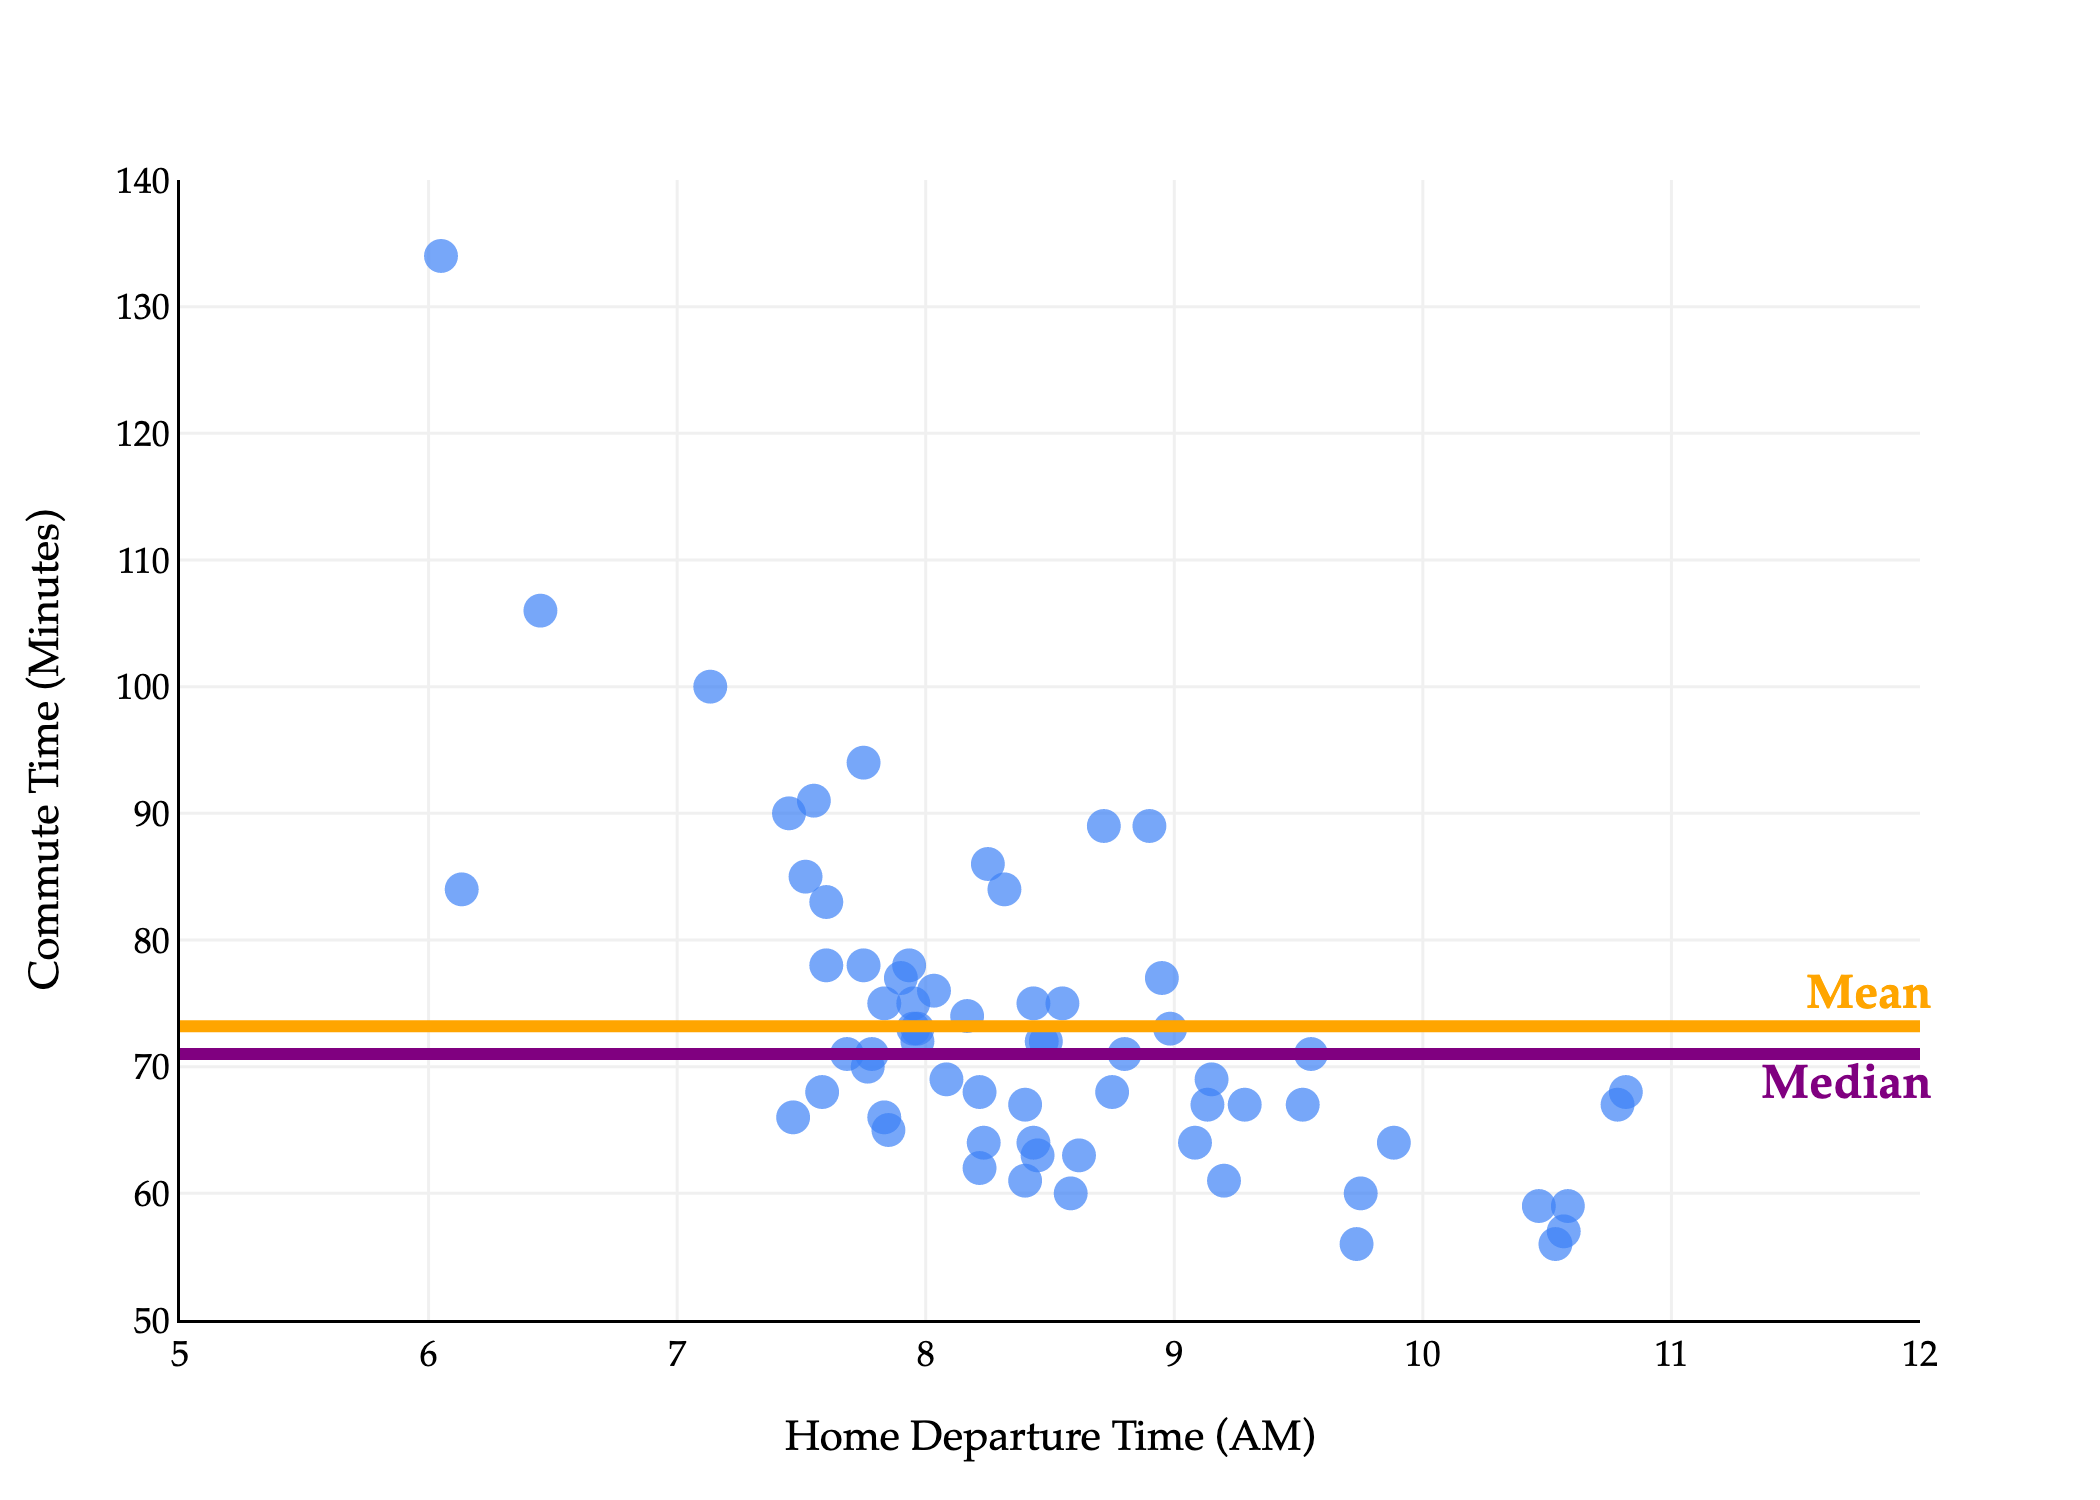

In [78]:
import pandas as pd
import numpy as np
import plotly.express as px

df = pd.read_csv('data/commute-times.csv')
y_mean = df['minutes'].mean()
y_median = df['minutes'].median()

fig = px.scatter(
    df,
    x='departure_hour',
    y='minutes',
    size=np.ones(len(df)) * 50,
    size_max=8
)

fig.add_hline(
    y=y_mean,
    line_color='orange',
    line_width=4
)
fig.add_hline(
    y=y_median,
    line_color='purple',
    line_width=4
)

fig.add_annotation(
    xref="paper",
    yref="y",
    x=1.01,
    y=y_mean,
    text="<b>Mean</b>",
    showarrow=False,
    font=dict(color="orange", size=16),
    align="left",
    yshift=10
)
fig.add_annotation(
    xref="paper",
    yref="y",
    x=1.01,
    y=y_median-5,
    text="<b>Median</b>",
    showarrow=False,
    font=dict(color="purple", size=16),
    align="left",
    yshift=10
)

fig.update_xaxes(
    title='Home Departure Time (AM)',
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
    range=[5, 12]
)
fig.update_yaxes(
    title='Commute Time (Minutes)',
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
)
fig.update_traces(marker_color="#3D81F6", marker_line_width=0)
fig.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=60, r=60, t=60, b=60),
    width=700,
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        color="black"
    ),
    showlegend=False,
)
fig.show(renderer='png', scale=3)


Depending on your criteria for what makes a good or bad prediction (i.e., the loss function you choose), optimal model parameters may change.

:::{tip} Activity 2 (🎥 walkthrough video!)
:class: dropdown

Suppose we have a dataset of $n = 13$ numbers, such that:

$$0 < y_1 \leq y_2 \leq \ldots \leq y_{13}$$

Given that $y_8 - y_7 > 1$ and $y_9 - y_8 > 1$, how does the value of $R_\text{abs}(y_8 - 1)$ compare to the value of $R_\text{abs}(y_8 + 1)$? Can you determine which is bigger, and by how much?

<iframe width="560" height="315" src="https://www.youtube.com/embed/ibzbb1aO_gI?si=3jfxHIyEvaTmtPgz" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share" allowfullscreen></iframe>

:::

---

Next, we'll compare absolute loss to squared loss and see how different loss choices change the optimal constant model.